# Tutorial: order parameters on reference structures

Four deliberately constructed on-lattice anion configurations for a
`6 x 6 x 6` MX3 supercell, with each of the five `chainorder` order
parameters applied and the output compared to the expected signature of
each structure. All four structures are at XO2F stoichiometry (1/3 F).

See `docs/concepts.md` for the conceptual background on the data model
and each order parameter; this notebook assumes that material.

Dependencies beyond `chainorder`: `numpy`, `matplotlib`, `ase`.


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms

from chainorder import SublatticeOccupation, order_params

N = 6             # supercell size (cubic)
a = 3.9           # lattice parameter, angstrom (arbitrary for on-lattice analysis)
rng = np.random.default_rng(0)

# Grid indices, shared by all structure builders.
ii, jj, kk = np.meshgrid(np.arange(N), np.arange(N), np.arange(N), indexing="ij")


A small helper builds an ASE `Atoms` object from three per-direction
occupation arrays. `ox[i, j, k] == 1` places F at the x-edge midpoint
`(i + 1/2, j, k) * a`; similarly for `oy` (at `(i, j + 1/2, k) * a`)
and `oz` (at `(i, j, k + 1/2) * a`). `0` entries are O.


In [2]:
def build_atoms(ox, oy, oz, N=N, a=a, cation="Nb"):
    '''Build an on-lattice MX3 ASE Atoms from three per-direction occupations.'''
    cat_pos = np.stack([ii, jj, kk], axis=-1).reshape(-1, 3).astype(float) * a
    cat_sym = [cation] * (N ** 3)

    x_pos = np.stack([ii + 0.5, jj, kk], axis=-1).reshape(-1, 3) * a
    x_sym = np.where(ox.astype(bool), "F", "O").reshape(-1).tolist()

    y_pos = np.stack([ii, jj + 0.5, kk], axis=-1).reshape(-1, 3) * a
    y_sym = np.where(oy.astype(bool), "F", "O").reshape(-1).tolist()

    z_pos = np.stack([ii, jj, kk + 0.5], axis=-1).reshape(-1, 3) * a
    z_sym = np.where(oz.astype(bool), "F", "O").reshape(-1).tolist()

    positions = np.concatenate([cat_pos, x_pos, y_pos, z_pos])
    symbols = cat_sym + x_sym + y_sym + z_sym
    return Atoms(
        symbols=symbols,
        positions=positions,
        cell=np.diag([N * a, N * a, N * a]),
        pbc=True,
    )


## Reference structures


### 1. Random

Each anion site is F independently with probability 1/3. No ordering:
a high-temperature MC snapshot in miniature.


In [3]:
p_F = 1 / 3
ox = (rng.random((N, N, N)) < p_F).astype(int)
oy = (rng.random((N, N, N)) < p_F).astype(int)
oz = (rng.random((N, N, N)) < p_F).astype(int)
atoms_random = build_atoms(ox, oy, oz)
print(f"F fraction: {(ox.sum() + oy.sum() + oz.sum()) / (3 * N ** 3):.3f}")


F fraction: 0.301


### 2. OOF chains, phases coupled for uniform cis coordination

Period-3 F (one F per three sites) on each chain in each direction, with
inter-chain phases chosen so that every cation has exactly 2 F
neighbours sitting on two different axes (i.e. cis). The phase rule is:

- x-chain at lateral `(j, k)`: F at `i = (j + k) mod 3`.
- y-chain at lateral `(i, k)`: F at `j = (i - k) mod 3`.
- z-chain at lateral `(i, j)`: F at `k = (i - j + 1) mod 3`.

(Other phase relationships give OOF on each chain but different cis/trans
coordination patterns; structure 3 below uses uncorrelated phases.)


In [4]:
ox = ((ii % 3) == ((jj + kk) % 3)).astype(int)
oy = ((jj % 3) == ((ii - kk) % 3)).astype(int)
oz = ((kk % 3) == ((ii - jj + 1) % 3)).astype(int)
atoms_allcis = build_atoms(ox, oy, oz)
print(f"F fraction: {(ox.sum() + oy.sum() + oz.sum()) / (3 * N ** 3):.3f}")


F fraction: 0.333


### 3. OOF chains with uncorrelated phases

Each chain still has period-3 F, but the phase of each chain is chosen
independently at random. The chains are individually ordered but their
period-3 patterns are uncorrelated with each other.


In [5]:
rng_phases = np.random.default_rng(1)
px = rng_phases.integers(0, 3, size=(N, N))   # phase of x-chain at (j, k)
py = rng_phases.integers(0, 3, size=(N, N))   # phase of y-chain at (i, k)
pz = rng_phases.integers(0, 3, size=(N, N))   # phase of z-chain at (i, j)

ox = ((ii % 3) == px[jj, kk]).astype(int)
oy = ((jj % 3) == py[ii, kk]).astype(int)
oz = ((kk % 3) == pz[ii, jj]).astype(int)
atoms_uncorrelated = build_atoms(ox, oy, oz)
print(f"F fraction: {(ox.sum() + oy.sum() + oz.sum()) / (3 * N ** 3):.3f}")


F fraction: 0.333


### 4. Period-2 on x and y, all-O on z (different ordering topology)

Alternating `OFOF...` along x and y-oriented chains, but no F at all on
the z-sublattice. Each cation ends up with exactly 2 F, one from the
x-axis and one from the y-axis -- again cis, but with different chain
periodicity from structure 2.


In [6]:
ox = ((ii % 2) == 1).astype(int)
oy = ((jj % 2) == 1).astype(int)
oz = np.zeros((N, N, N), dtype=int)
atoms_ofof = build_atoms(ox, oy, oz)
print(f"F fraction: {(ox.sum() + oy.sum() + oz.sum()) / (3 * N ** 3):.3f}")


F fraction: 0.333


### Wrap as `SublatticeOccupation`s

Each ASE `Atoms` is passed to `SublatticeOccupation.from_atoms` to
produce the data structure the order parameters consume.


In [7]:
structures = {
    "random":         SublatticeOccupation.from_atoms(atoms_random,      N=N, species="F"),
    "all-cis":        SublatticeOccupation.from_atoms(atoms_allcis,      N=N, species="F"),
    "uncorrelated":   SublatticeOccupation.from_atoms(atoms_uncorrelated, N=N, species="F"),
    "ofof":           SublatticeOccupation.from_atoms(atoms_ofof,        N=N, species="F"),
}
labels = list(structures.keys())
colors = {"random": "#888888", "all-cis": "#1f77b4", "uncorrelated": "#ff7f0e", "ofof": "#2ca02c"}


## `chain_fft`: per-chain Fourier spectrum


For each chain, `chain_fft` returns the DFT of its species sequence.
We plot the mean `|F(k)|^2` across all chains of one direction, per
structure.

Expected signatures:

- **random**: noise near `1/(3 N)` at every `k`.
- **all-cis** and **uncorrelated**: peaks at `k = 0, N/3, 2 N/3` for
  each direction (period-3 chains). Equal in both structures -- phase
  correlations between chains don't affect per-chain amplitude.
- **ofof**: peaks at `k = 0` and `k = N/2` for x and y directions
  (period-2). Zero spectrum for z (uniformly O).


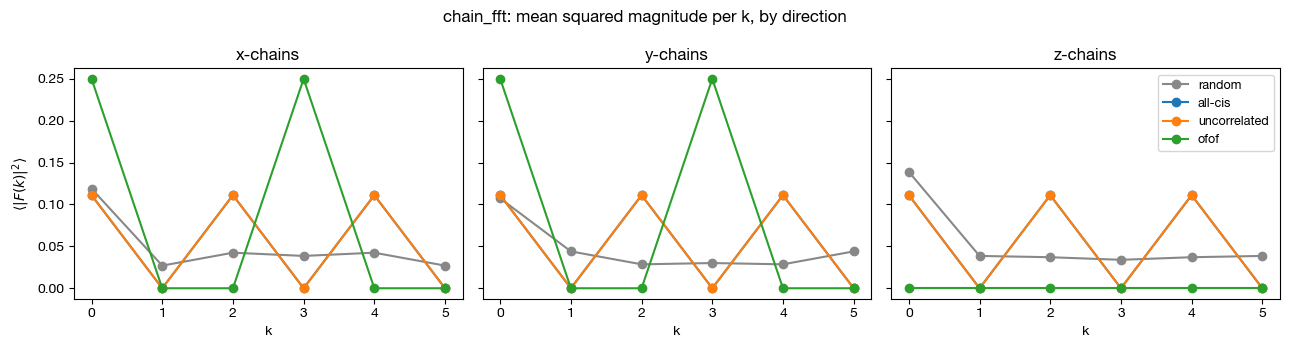

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, direction, view_attr in zip(axes, "xyz", ("x", "y", "z")):
    ax.set_title(f"{direction}-chains")
    ax.set_xlabel("k")
    for name in labels:
        view = getattr(structures[name], view_attr)
        spectrum = np.abs(order_params.chain_fft(view)) ** 2      # (lat0, lat1, N)
        mean_spectrum = spectrum.mean(axis=(0, 1))
        ax.plot(np.arange(N), mean_spectrum, marker="o", label=name, color=colors[name])
    ax.set_xticks(np.arange(N))
axes[0].set_ylabel(r"$\langle |F(k)|^2 \rangle$")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle("chain_fft: mean squared magnitude per k, by direction")
fig.tight_layout()
plt.show()


The period-3 peaks for **all-cis** and **uncorrelated** sit at
`k = 2` and `k = 4` (= `N/3` and `2 N/3` for `N = 6`); the period-2
peak for **ofof** sits at `k = 3` (= `N/2`). The **random** trace
hovers near the noise floor everywhere except `k = 0`. The z-panel
for **ofof** is flat at zero -- its z-chains contain no F.


## `along_chain_correlation`: along-chain pair correlation $g(r)$


Expected signatures:

- **random**: `g(0)` equals the variance `p(1-p) ~ 2/9`; `g(r) ~ 0`
  for `r > 0`.
- **all-cis** and **uncorrelated**: `g(r) = 2/9` at `r = 0, 3`;
  `g(r) = -1/9` at `r = 1, 2, 4, 5`. Identical between the two --
  per-chain correlations are unaffected by inter-chain phases.
- **ofof**: `g(r) = 1/4` at even `r`, `g(r) = -1/4` at odd `r` for
  x and y directions; all zeros for z (the z-chains are constant, so
  their variance and all their pair correlations are zero).


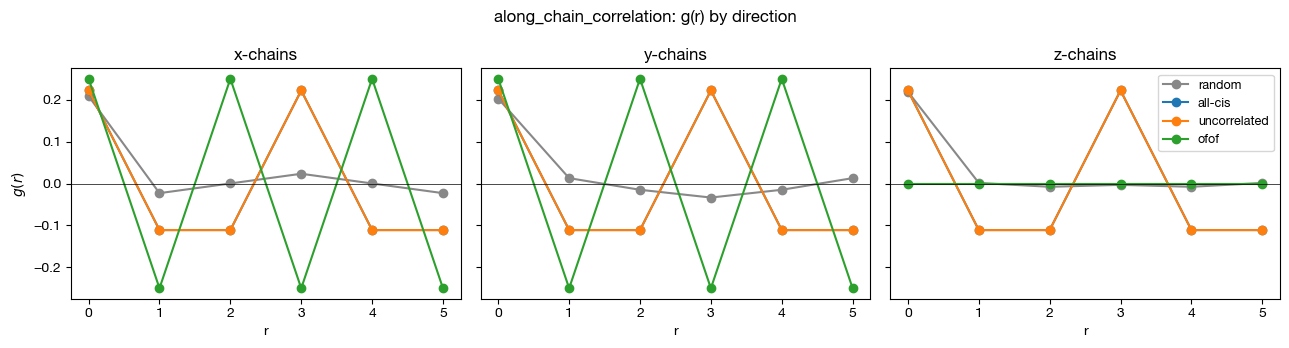

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, direction, view_attr in zip(axes, "xyz", ("x", "y", "z")):
    ax.set_title(f"{direction}-chains")
    ax.set_xlabel("r")
    for name in labels:
        view = getattr(structures[name], view_attr)
        g = order_params.along_chain_correlation(view)
        ax.plot(np.arange(N), g, marker="o", label=name, color=colors[name])
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xticks(np.arange(N))
axes[0].set_ylabel(r"$g(r)$")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle("along_chain_correlation: g(r) by direction")
fig.tight_layout()
plt.show()


For **ofof** the z-panel is flat at zero because every z-chain is
uniformly O: the species flag is constant, so its variance (which is
`g(0)`) is zero, and so are the lagged correlations.


## `motif_counts`: cyclic-motif frequencies


Count classes of length-3 motifs. For a period-3 OOF chain, every
length-3 window lies in the `OOF`-class (all other classes get zero
count). A period-2 alternating chain splits half-and-half between the
`OOF`-class and `OFF`-class. A random chain spreads its counts across
all classes. A uniformly O chain is entirely in the `OOO`-class.

We sum counts over all chains of one direction to get a per-class
total, then plot the totals as a bar chart.


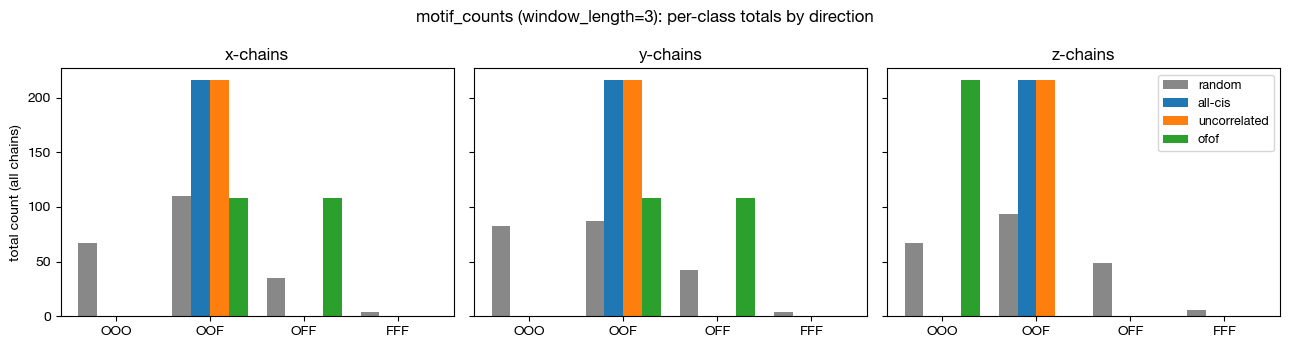

In [10]:
w = 3
all_classes = {
    (0, 0, 0): "OOO",
    (0, 0, 1): "OOF",
    (0, 1, 1): "OFF",
    (1, 1, 1): "FFF",
}
class_order = list(all_classes.keys())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, direction, view_attr in zip(axes, "xyz", ("x", "y", "z")):
    ax.set_title(f"{direction}-chains")
    x_positions = np.arange(len(class_order))
    bar_width = 0.2
    for i, name in enumerate(labels):
        view = getattr(structures[name], view_attr)
        counts = order_params.motif_counts(view, window_length=w)
        totals = [counts.get(cls, np.zeros_like(view[..., 0])).sum() for cls in class_order]
        ax.bar(x_positions + i * bar_width - 1.5 * bar_width, totals,
               width=bar_width, label=name, color=colors[name])
    ax.set_xticks(x_positions)
    ax.set_xticklabels([all_classes[c] for c in class_order])
axes[0].set_ylabel("total count (all chains)")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle("motif_counts (window_length=3): per-class totals by direction")
fig.tight_layout()
plt.show()


For **all-cis** and **uncorrelated** every count sits in the
`OOF`-class on all three directions -- both have per-chain period-3
ordering. **ofof** puts half its x and y counts in `OOF` and half in
`OFF` (the two motif classes produced by an `OFOF...` window sweep);
its z-chains are entirely in the `OOO`-class. **random** spreads
counts across all four classes with the multinomial weights appropriate
to `p_F = 1/3`.


## `inter_chain_correlation`: lateral coherence of a chain harmonic


Computed on `occ.x` at `period=3`. Expected:

- **all-cis**: the phase rule `px(j, k) = (j + k) mod 3` gives `|G| ~ 1`
  for all lateral lags, with a linear phase gradient along both
  lateral directions.
- **uncorrelated**: each x-chain has a random period-3 phase, so
  `|G| ~ 0` off the origin.
- **random**: raises -- no coherent period-3 amplitude on each chain
  (some chains may have zero weight, but others have noise-level
  amplitudes; the normalisation is still well-defined, so we handle
  the potential error and skip plotting if it fires).
- **ofof**: raises -- the x-chains are period-2, so `|phi|^2 = 0` at
  the period-3 harmonic and the correlation is undefined. We catch
  this and skip.


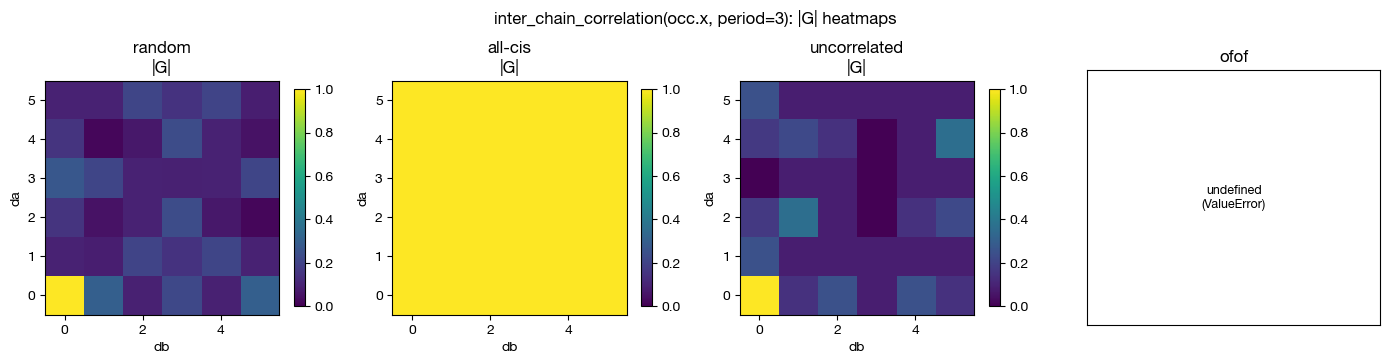

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, name in zip(axes, labels):
    view = structures[name].x
    try:
        G = order_params.inter_chain_correlation(view, period=3)
        im = ax.imshow(np.abs(G), vmin=0, vmax=1, origin="lower", cmap="viridis")
        ax.set_title(f"{name}\n|G|")
        ax.set_xlabel("db")
        ax.set_ylabel("da")
        fig.colorbar(im, ax=ax, shrink=0.85)
    except ValueError as e:
        ax.text(0.5, 0.5, f"undefined\n({type(e).__name__})",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=9)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle("inter_chain_correlation(occ.x, period=3): |G| heatmaps")
fig.tight_layout()
plt.show()


**all-cis**'s `|G| = 1` across the whole lateral plane reflects the
deterministic phase rule `(j + k) mod 3` -- every pair of chains
differs by a fixed phase offset and the amplitude-weighted correlation
is perfectly coherent. **uncorrelated**'s `|G|` drops off the origin
(with statistical noise from the finite supercell). **ofof** fails the
"non-zero amplitude at the chosen harmonic" requirement: its x-chains
are period-2, so the period-3 Fourier coefficient is zero on every
chain.


## `structure_factor`: 3D diffuse-scattering intensity


`structure_factor(occ)` returns `|F(kx, ky, kz)|^2` on the full `6 x 6 x 6`
reciprocal grid. To visualise in 2D, we project along each axis in
turn with a *max projection* (`max |F|^2` over one axis): this
preserves any peak regardless of its position on the collapsed axis,
so off-axis peaks still show up.

Expected peak positions:

- **random**: only a DC peak at `(0, 0, 0)` with `|F|^2 = 1`; elsewhere
  a small noise floor.
- **all-cis**: peaks at `(0, 0, 0)` (|F|^2 = 1) and at the *off-axis*
  positions `(4, 2, 2)` and `(2, 4, 4)` (|F|^2 = 4/9 each). The
  coupled phase rule for the three sublattices produces a superlattice
  with peaks at wavevectors satisfying `kx - ky - kz = 0 mod 3`, not
  on the principal axes.
- **uncorrelated**: DC peak, plus *rods* of non-zero intensity along
  `kx = 2, 4` (from the x-sublattice), `ky = 2, 4` (from y), and
  `kz = 2, 4` (from z). The rod intensities are noise-like along the
  orthogonal axes because the inter-chain phases are random.
- **ofof**: peaks at `(0, 0, 0)` (|F|^2 = 1), and period-2 peaks at
  `(3, 0, 0)` and `(0, 3, 0)` (|F|^2 = 1/4 each). Nothing on the
  `kz` axis (z-sublattice has no F).


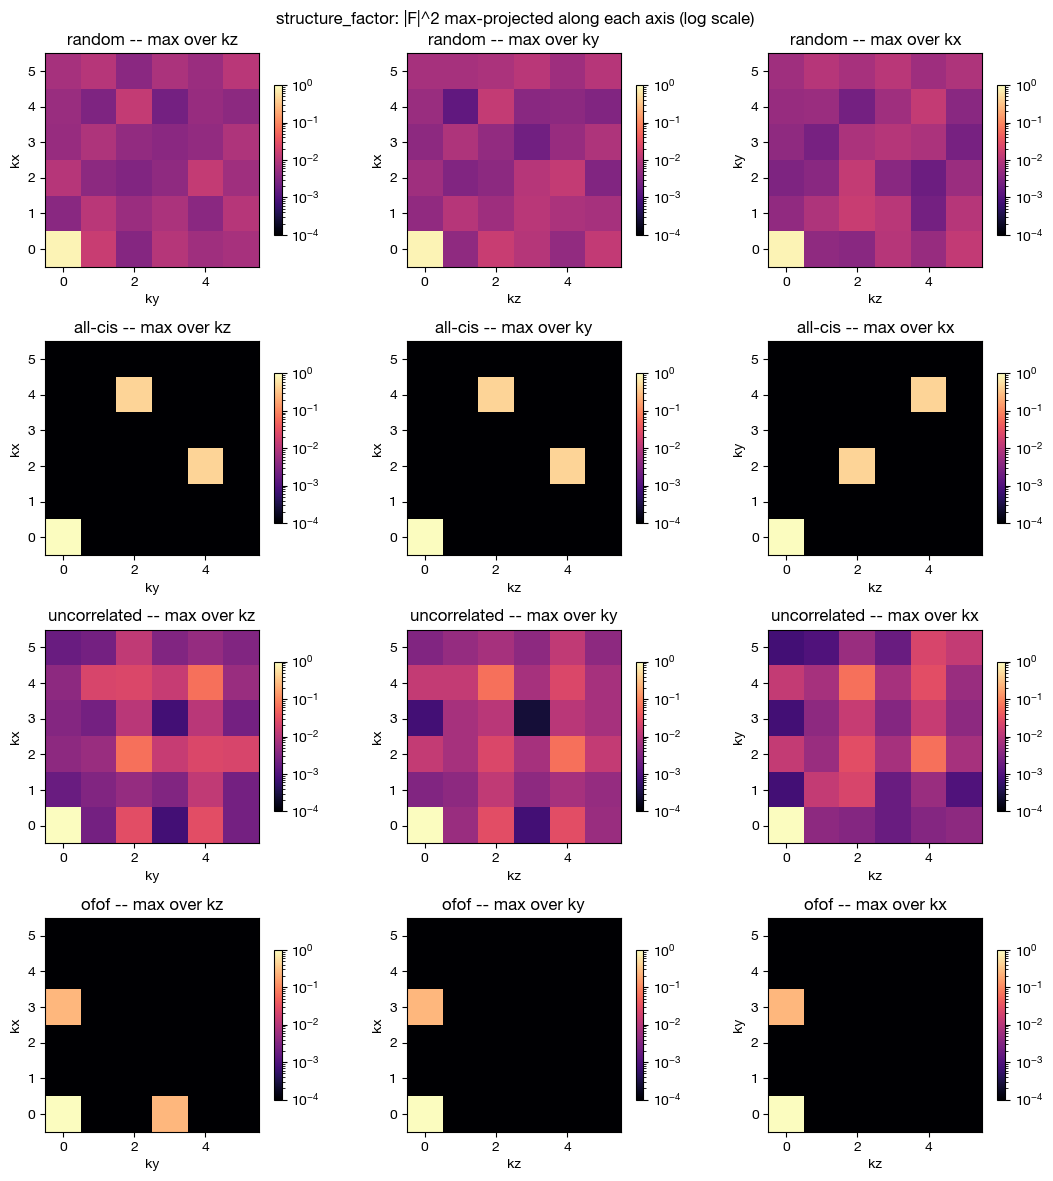

In [12]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(len(labels), 3, figsize=(11, 3 * len(labels)))
proj_names = [
    ("max over kz", "kx", "ky"),
    ("max over ky", "kx", "kz"),
    ("max over kx", "ky", "kz"),
]
norm = LogNorm(vmin=1e-4, vmax=1, clip=True)
for i, name in enumerate(labels):
    F = order_params.structure_factor(structures[name])       # (Nx, Ny, Nz)
    intensity = np.abs(F) ** 2
    projections = [intensity.max(axis=2), intensity.max(axis=1), intensity.max(axis=0)]
    for j, (proj_label, x_label, y_label) in enumerate(proj_names):
        ax = axes[i, j]
        im = ax.imshow(projections[j], origin="lower", cmap="magma", norm=norm)
        ax.set_title(f"{name} -- {proj_label}")
        ax.set_xlabel(y_label)
        ax.set_ylabel(x_label)
        fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("structure_factor: |F|^2 max-projected along each axis (log scale)")
fig.tight_layout()
plt.show()


**all-cis** shows the DC peak at `(0, 0, 0)` plus two off-axis peaks
in each projection (at `(4, 2)` and `(2, 4)` on the `(kx, ky)`
projection, for example) -- these are the superlattice peaks that
principal-axis slices would have missed.

**uncorrelated** shows DC plus rods: its x-sublattice contributes at
any wavevector with `kx in {2, 4}`, so the `max over kz` projection
shows a full row of intensity at `kx = 2` and `kx = 4` (similarly for
the other projections). The rod intensity varies position-to-position
because the random per-chain phases give a noise-like amplitude
distribution; max-projecting picks out the brightest value along the
collapsed axis.

**ofof**'s period-2 peaks at `(3, 0, 0)` and `(0, 3, 0)` are clear in
the `max over kz` projection; the `max over kx` and `max over ky`
projections each show one of the two peaks. No signal involving
`kz != 0` in any projection -- the z-sublattice is empty.

**random** is a flat background with the DC peak.


## Summary

The four reference structures exercise every order parameter:

| structure      | `chain_fft`                  | `along_chain_correlation`    | `motif_counts` (w=3)          | `inter_chain_correlation` (period=3) | `structure_factor`                           |
|----------------|------------------------------|------------------------------|-------------------------------|--------------------------------------|----------------------------------------------|
| random         | noise floor                  | ~0 off origin                | all classes populated         | ~0 off origin                        | only DC                                      |
| all-cis        | peaks at `k = N/3, 2N/3`     | recurring peaks at `r = 3`   | entirely `OOF`                | `|G| = 1` everywhere                 | DC + off-axis peaks at `(4, 2, 2)`, `(2, 4, 4)` |
| uncorrelated   | peaks at `k = N/3, 2N/3`     | recurring peaks at `r = 3`   | entirely `OOF`                | `|G| ~ 0` off origin                 | DC + rods at `kx, ky, kz = 2, 4`             |
| ofof           | peaks at `k = N/2` on x,y    | 1/4 / -1/4 on x,y; zero on z | `OOF`+`OFF` on x,y; `OOO` on z| raises (period-3 undefined on x)     | DC + period-2 peaks at `(3, 0, 0)`, `(0, 3, 0)` |

The two OOF structures have identical per-chain observables
(`chain_fft`, `along_chain_correlation`, `motif_counts`) because
those observables are blind to inter-chain phase relationships.
`inter_chain_correlation` and `structure_factor` both resolve the
distinction: `|G|` is the direct per-chain-pair phase check, and the
3D structure factor shifts between sharp off-axis peaks (**all-cis**,
coherent phase rule) and smeared rods (**uncorrelated**, random
phases).
